## Pixel Removal Per Channel only from the QRS complex
Used the averaged heart beat data to get these results

To get the data run the following first:

`python removal_rmse_script.py`

Use the following parameters in the `main` function:

```python
for interval in intervals:
    logger.info(f"Starting for removal interval: {interval}")

    for channel in range(12):
        # Run this in a for loop for channel by channel removal
        # removing area from all channels at a time, use
        # channel = [x for x in range(12)]
        # For the whole range, use pixel_range=(1900, 2250)
        df_err, df_all_subjects_and_pixels = calculate_removal_error(
            data_array_loc=DATA_ARRAY,
            interval=interval,
            total_subjects=0,
            n_idx=1,
            pixel_range=(2030, 2070),  # just for the QRS complex and some extra pixels
            channel=[channel],
            replace_step=False,
        )

        df_err.to_csv(f"{results_dir}/rmse_qrs_{interval}pixels_chan{channel}_6k_sub.csv", index=False)
        df_all_subjects_and_pixels.to_csv(
            f"{results_dir}/all_subjects_qrs_pixels_{interval}pixels_chan{channel}_6k_sub.csv", index=False
        )

```

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

import sys
sys.path.append('../scripts/')
from constants import waves
from evaluate_script import predict

INPUT_DIR = '../output/removal_data_repl_interpol_chan_qrs_6k'

In [3]:
def plot_pixel_channel_removal_error(pixels, channel):
    file = f'all_subjects_qrs_pixels_{pixels}pixels_chan{channel}_6k_sub.csv'
    filepath = f'{INPUT_DIR}/{file}'
    if Path(filepath).is_file():
        df = pd.read_csv(filepath)
    else:
        FileNotFoundError(f'{filepath} does not exist')
    df.loc[:, 'central_pixel'] = df['start_pixel'] + (pixels // 2)
    df.loc[:, 'abs_error'] = np.abs(df['raw_prediction'] - df['replace_prediction'])
    df_pixel = df.groupby(
        'central_pixel'
    )[['replace_area', 'abs_error']].mean().reset_index()
    plt.figure(figsize=(12, 6))
    plt.plot(
        df_pixel['replace_area'],
        df_pixel['abs_error'],
        color='rosybrown',
        label="all ages/preds",
        alpha=0.2
    )

    for key, value in waves.items():
        if key not in ['P', 'P-Q', 'T']:
            wave_range = value[0]
            colour = value[1]
            wave_filt = df_pixel['central_pixel'].between(wave_range[0], wave_range[1])
            plt.plot(
                df_pixel[wave_filt]['replace_area'],
            df_pixel[wave_filt]['abs_error'],
            color=colour,
            linestyle=value[2],
            label=f'{key}'
        )
    plt.legend()
    plt.title(f"Mean Absolute Error vs Replace Area: pixels removed = {pixels}; channel = {channel}")
    plt.xlabel("Mean Replace Area for each pixel")
    plt.ylabel("Mean Absolute Error for each pixel")
    plt.show()

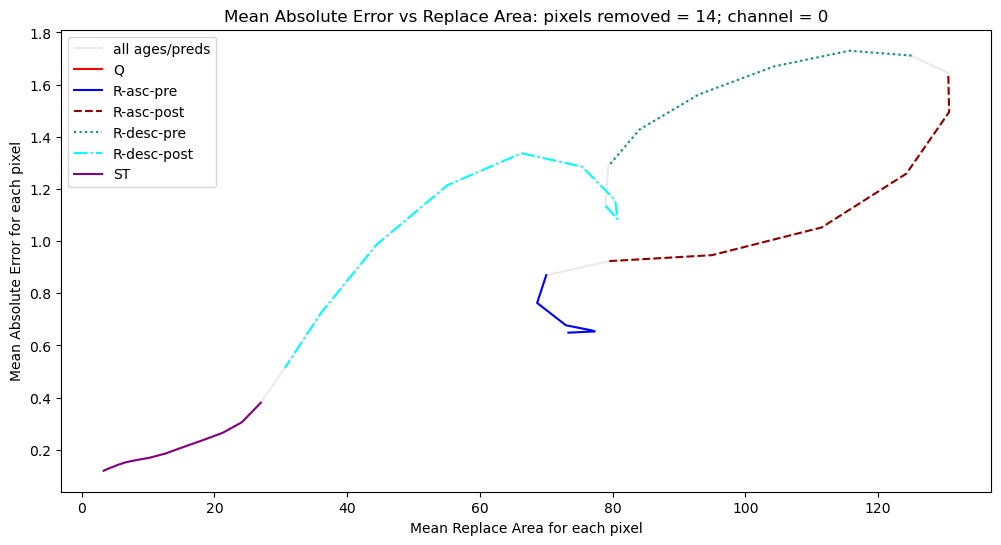

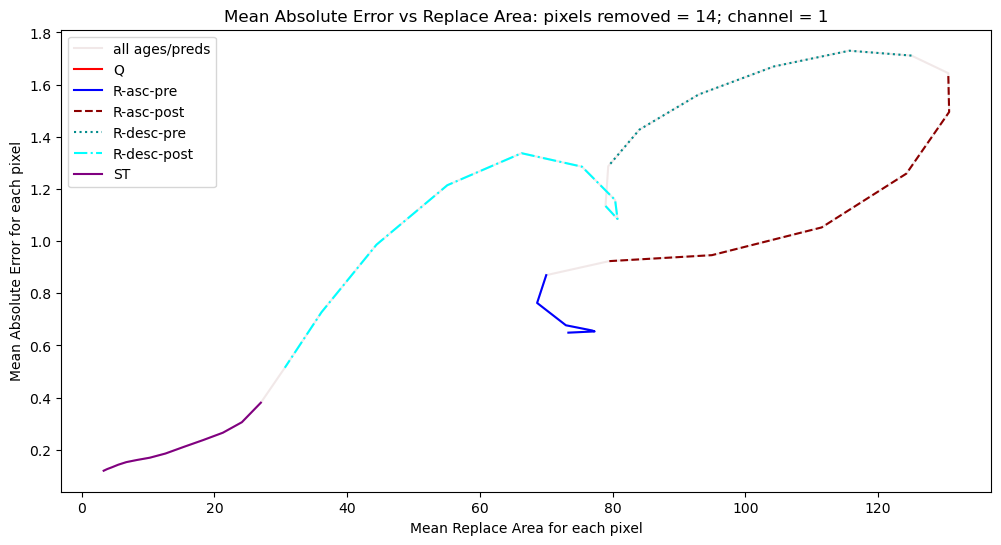

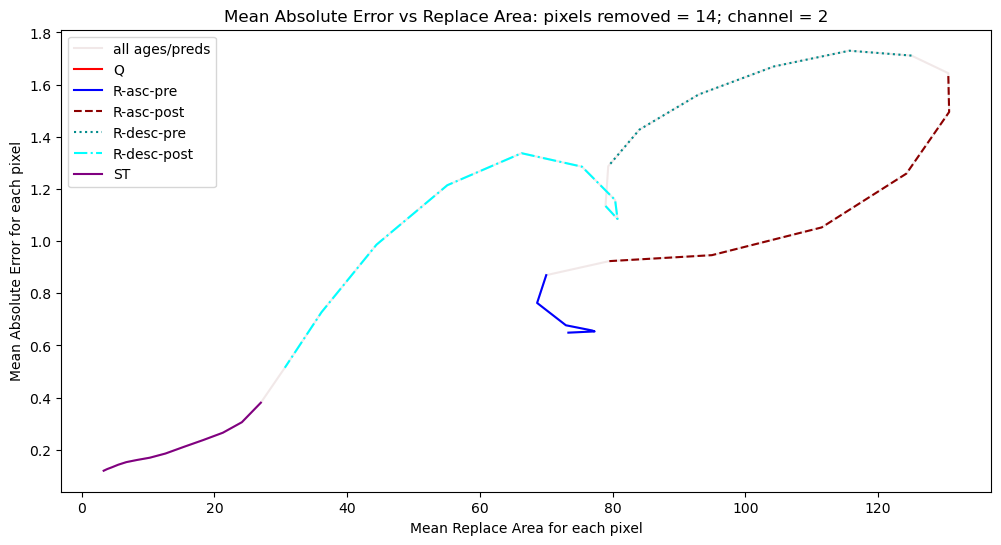

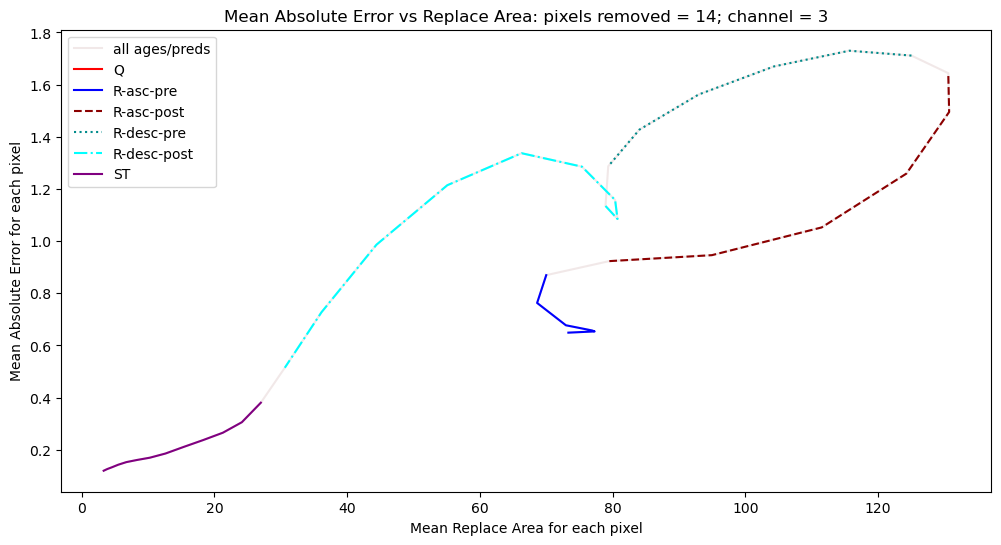

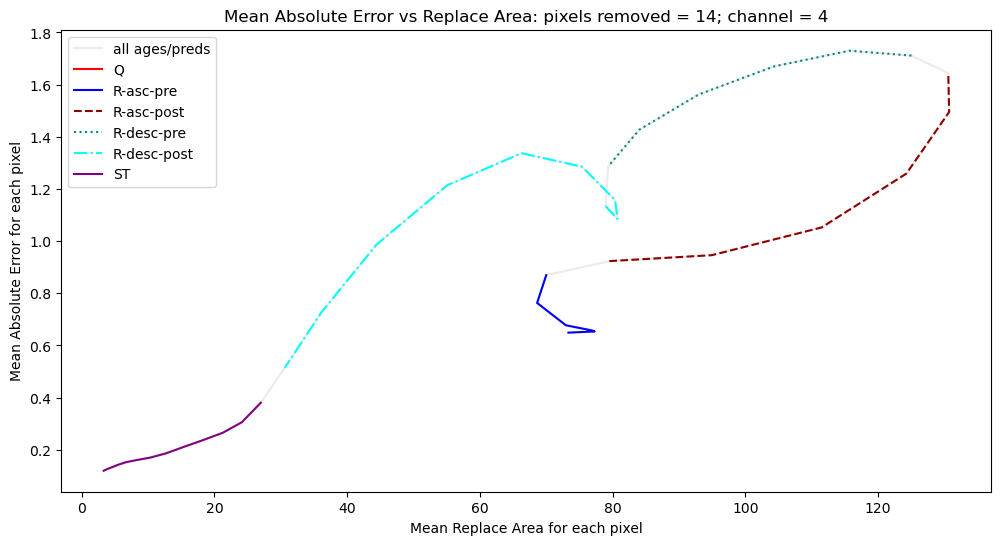

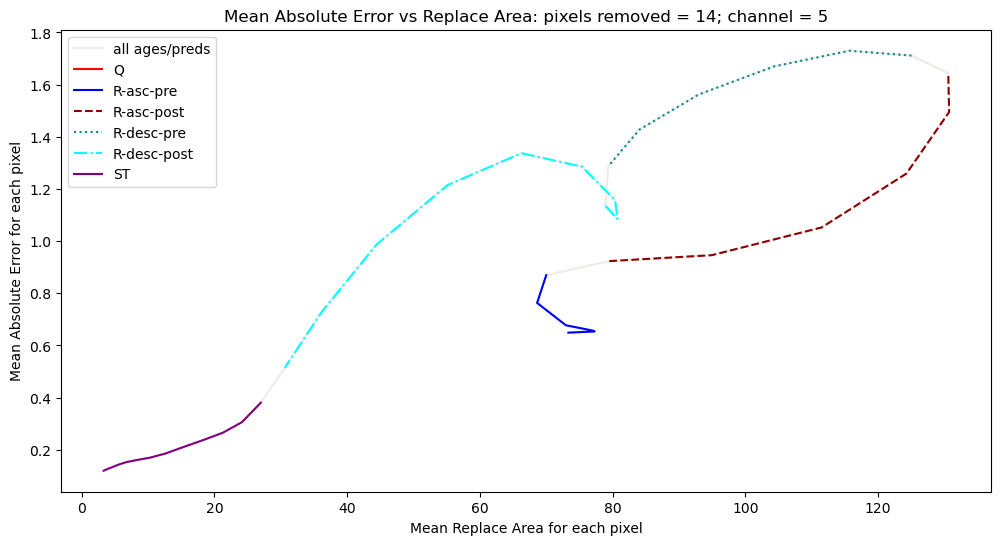

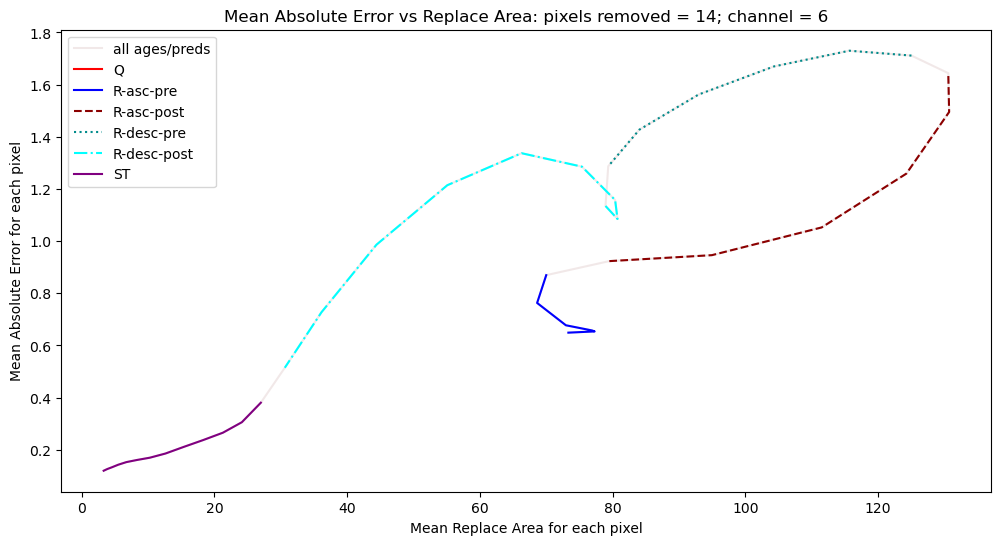

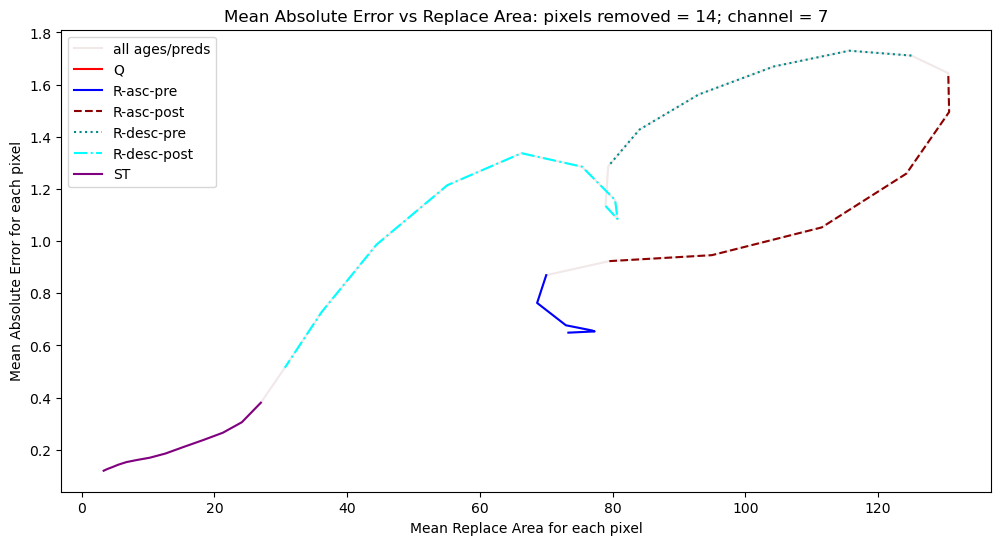

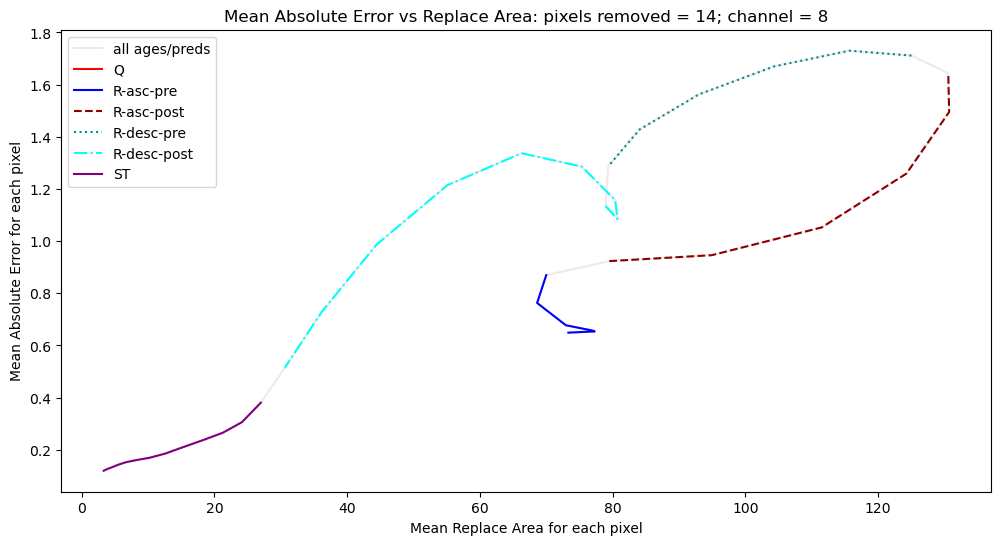

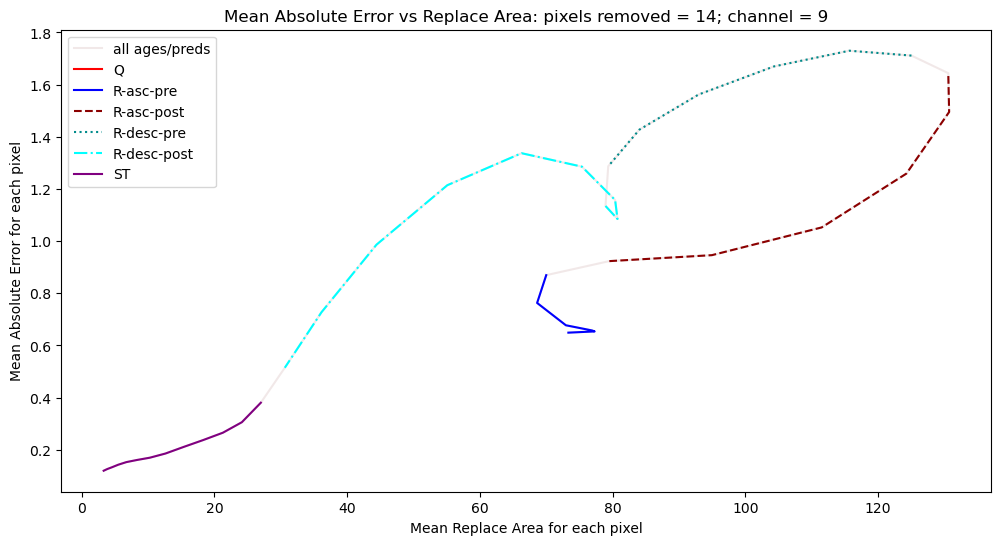

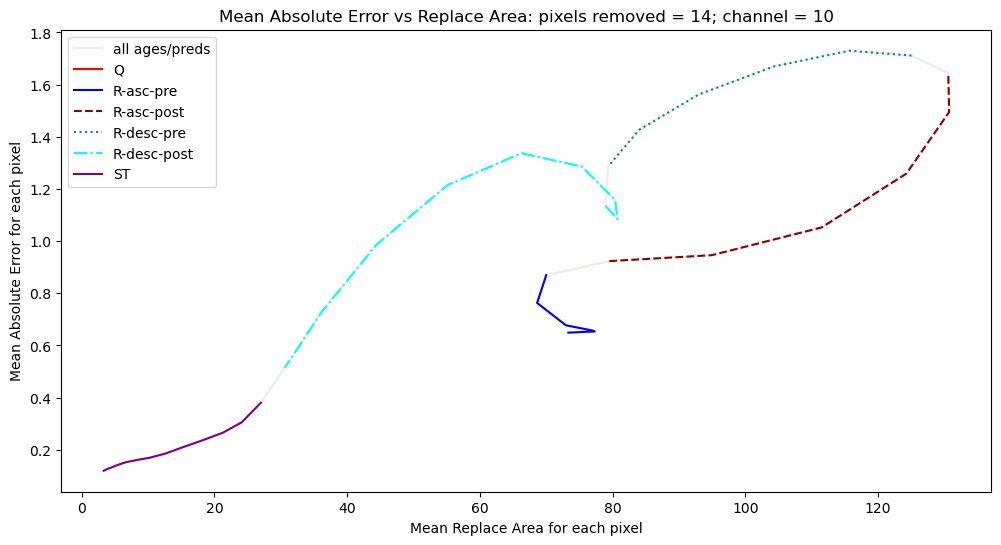

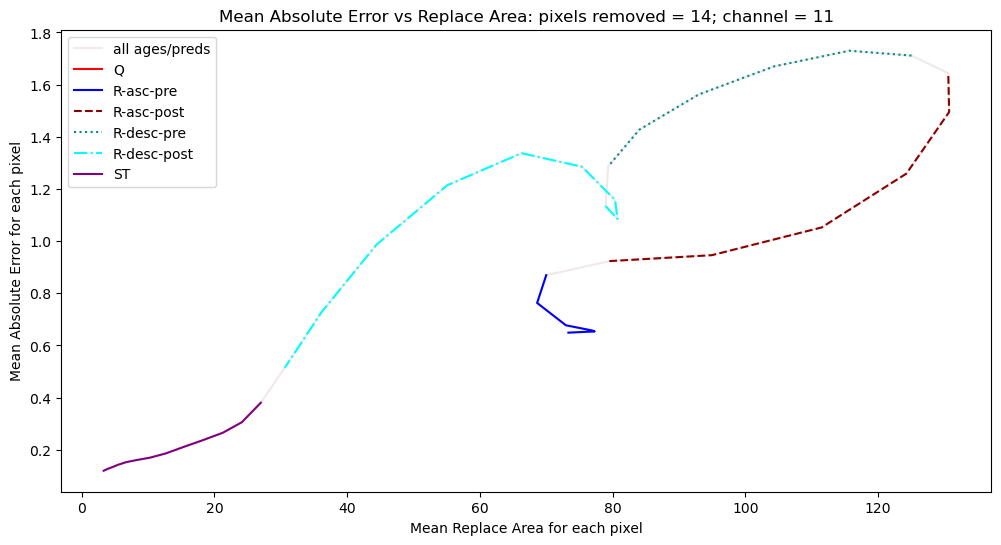

In [4]:
for channel in range(12):
    plot_pixel_channel_removal_error(pixels=14, channel=channel)

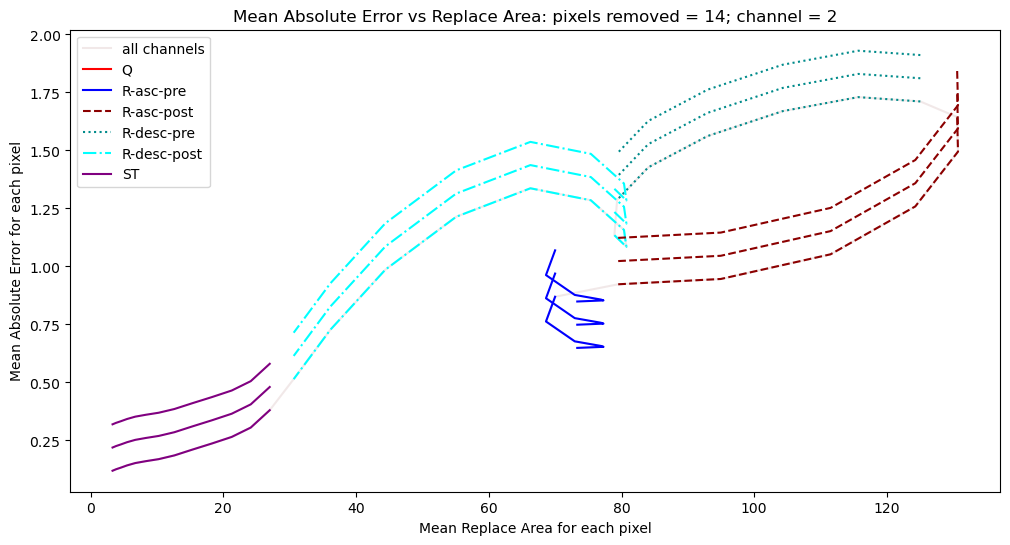

In [6]:
# overlay all channels plot

plt.figure(figsize=(12, 6))

for channel in range(3):
    pixels = 14
    file = f'all_subjects_qrs_pixels_{pixels}pixels_chan{channel}_6k_sub.csv'
    filepath = f'{INPUT_DIR}/{file}'
    if Path(filepath).is_file():
        df = pd.read_csv(filepath)
    else:
        FileNotFoundError(f'{filepath} does not exist')
    df.loc[:, 'central_pixel'] = df['start_pixel'] + (pixels // 2)
    df.loc[:, 'abs_error'] = np.abs(df['raw_prediction'] - df['replace_prediction'])
    df_pixel = df.groupby(
        'central_pixel'
    )[['replace_area', 'abs_error']].mean().reset_index()

    if channel == 0:
        plt.plot(
            df_pixel['replace_area'],
            df_pixel['abs_error'],
            color='rosybrown',
            label="all channels",
            alpha=0.2
        )
        for key, value in waves.items():
            if key not in ['P', 'P-Q', 'T']:
                wave_range = value[0]
                colour = value[1]
                wave_filt = df_pixel['central_pixel'].between(wave_range[0], wave_range[1])
                plt.plot(
                    df_pixel[wave_filt]['replace_area'],
                df_pixel[wave_filt]['abs_error'],
                color=colour,
                linestyle=value[2],
                label=f'{key}'
            )
    else:
        for key, value in waves.items():
            if key not in ['P', 'P-Q', 'T']:
                wave_range = value[0]
                colour = value[1]
                wave_filt = df_pixel['central_pixel'].between(wave_range[0], wave_range[1])
                plt.plot(
                    df_pixel[wave_filt]['replace_area'],
                df_pixel[wave_filt]['abs_error'] + channel / 10,  # add channel number to shift the plot up for visibility
                color=colour,
                linestyle=value[2],
            )
plt.legend()
plt.title(f"Mean Absolute Error vs Replace Area: pixels removed = {pixels}; channel = {channel}")
plt.xlabel("Mean Replace Area for each pixel")
plt.ylabel("Mean Absolute Error for each pixel")
plt.show()